C:\Users\pm5cd\AppData\Local\Temp\ipykernel_18724\1108215932.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(train_df['binary_label'], palette=["#2ecc71", "#e74c3c"])


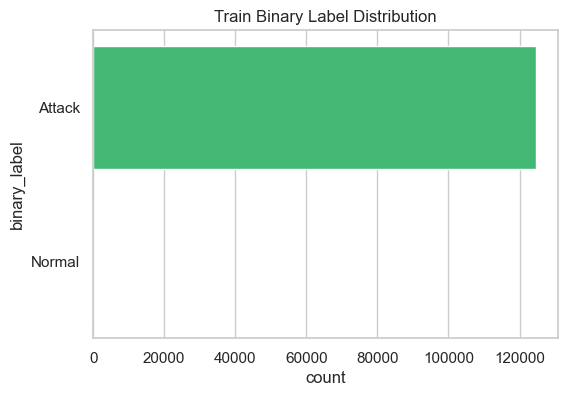

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_18724\1108215932.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(test_df['binary_label'], palette=["#3498db", "#e67e22"])


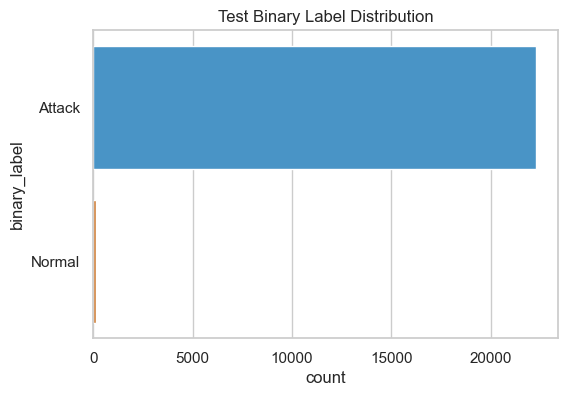

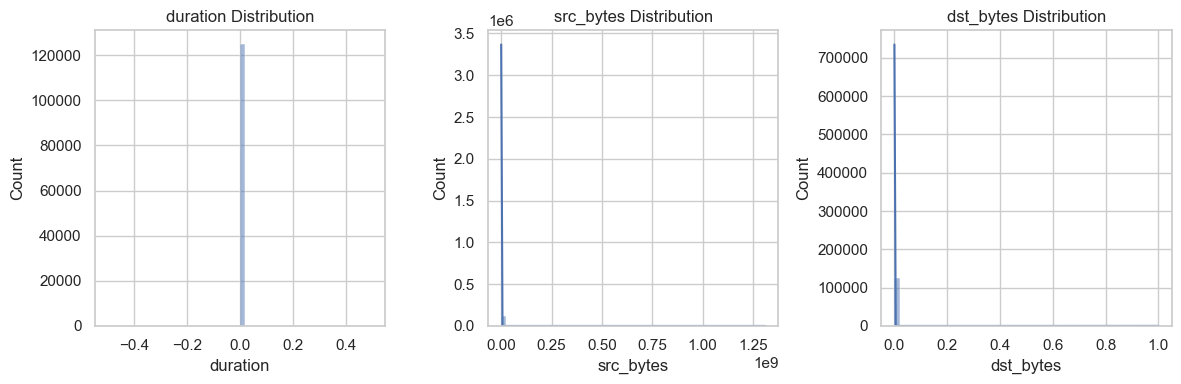

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_18724\1108215932.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='protocol_type', data=X_train, palette='pastel')


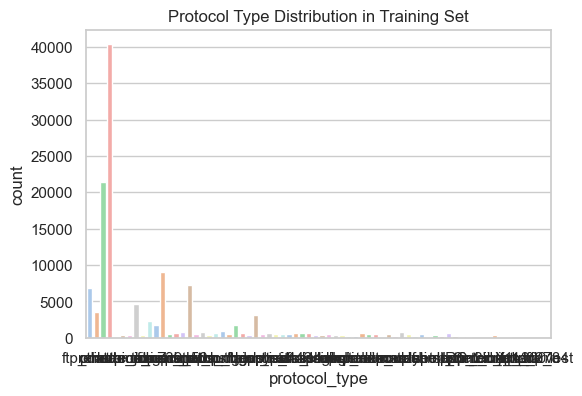


Training Logistic Regression

Training Decision Tree

Training Random Forest

Training Gradient Boosting

Model Performance Metrics:
                 Model  Train Accuracy  Train Sensitivity  Train Specificity  \
0  Logistic Regression        0.999607           0.999992           0.272727   
1        Decision Tree        1.000000           1.000000           1.000000   
2        Random Forest        1.000000           1.000000           1.000000   
3    Gradient Boosting        0.999511           0.999952           0.166667   

   Train Precision  Train F1  Train AUC  Test Accuracy  Test Sensitivity  \
0         0.999615  0.999803   0.013223       0.994513          1.000000   
1         1.000000  1.000000   0.000000       0.994424          0.999821   
2         1.000000  1.000000   0.000000       0.994513          1.000000   
3         0.999559  0.999755   0.648779       0.993978          0.999372   

   Test Specificity  Test Precision   Test F1  Test AUC  
0           0.00000       

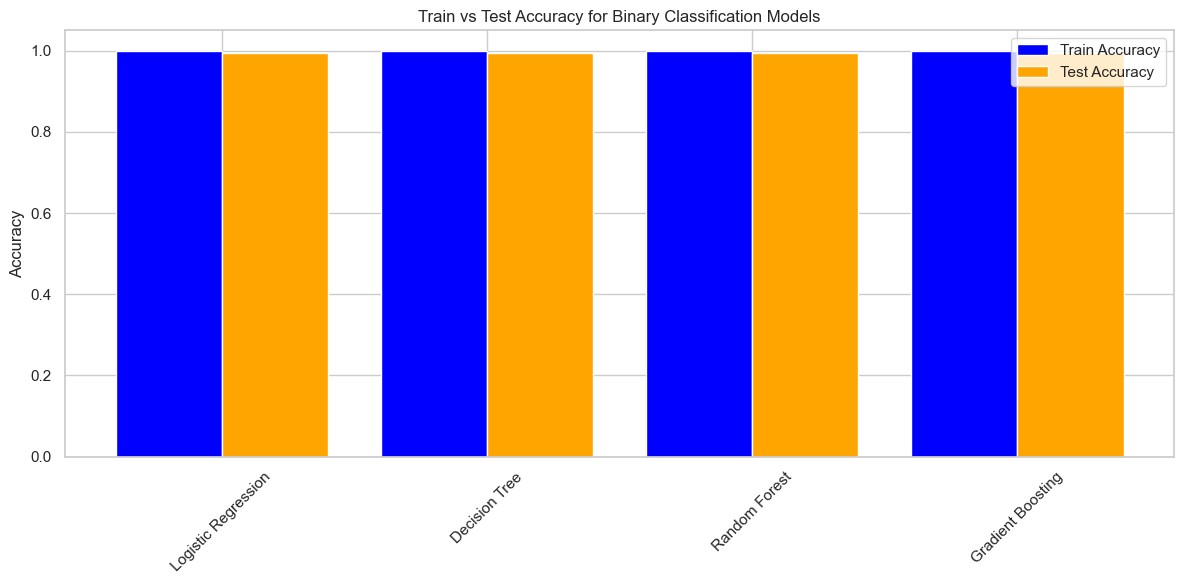

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

sns.set(style='whitegrid')

# Load dataset & columns
column_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label"
]

train_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTrain+.txt'
test_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTest+.txt'

train_df = pd.read_csv(train_file, names=column_names)
test_df = pd.read_csv(test_file, names=column_names)

# Map numeric labels to string names
label_map = {0:'normal',1:'neptune',2:'warezclient',3:'ipsweep',4:'portsweep',5:'teardrop',
             6:'nmap',7:'satan',8:'smurf',9:'guess_passwd',10:'pod',11:'buffer_overflow',
             12:'imap',13:'back',14:'land',15:'ftp_write',16:'multihop',17:'phf',
             18:'perl',19:'spy',20:'rootkit',21:'loadmodule'}

train_df['label'] = train_df['label'].map(label_map)
test_df['label'] = test_df['label'].map(label_map)

# Drop duplicates
train_df.drop_duplicates(inplace=True)
test_df.drop_duplicates(inplace=True)

# Create binary label Normal vs Attack
train_df['binary_label'] = train_df['label'].apply(lambda x: 'Normal' if x == 'normal' else 'Attack')
test_df['binary_label'] = test_df['label'].apply(lambda x: 'Normal' if x == 'normal' else 'Attack')

# Visualize Distribution
plt.figure(figsize=(6,4))
sns.countplot(train_df['binary_label'], palette=["#2ecc71", "#e74c3c"])
plt.title('Train Binary Label Distribution')
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(test_df['binary_label'], palette=["#3498db", "#e67e22"])
plt.title('Test Binary Label Distribution')
plt.show()

# Feature sets for training
X_train = train_df.drop(['label','binary_label'], axis=1)
y_train = train_df['binary_label']
X_test = test_df.drop(['label','binary_label'], axis=1)
y_test = test_df['binary_label']

categorical_features = ['protocol_type', 'service', 'flag']
numeric_features = [c for c in X_train.columns if c not in categorical_features]

# Fix numeric columns & fill NA
for col in numeric_features:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
X_train[numeric_features] = X_train[numeric_features].fillna(0)
X_test[numeric_features] = X_test[numeric_features].fillna(0)

# Visualize numeric distributions
plt.figure(figsize=(12,4))
for i,col in enumerate(['duration','src_bytes','dst_bytes']):
    plt.subplot(1,3,i+1)
    sns.histplot(X_train[col], bins=50, kde=True)
    plt.title(f'{col} Distribution')
plt.tight_layout()
plt.show()

# Visualize protocol_type categorical
plt.figure(figsize=(6,4))
sns.countplot(x='protocol_type', data=X_train, palette='pastel')
plt.title('Protocol Type Distribution in Training Set')
plt.show()

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Models to train
models = {
    'Logistic Regression': LogisticRegression(max_iter=300),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier()
}

# Compute metrics including sensitivity, specificity, precision, F1, AUC for binary classification
def compute_metrics(y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label='Attack')
    recall = recall_score(y_true, y_pred, pos_label='Attack')  # sensitivity
    specificity = recall_score(y_true, y_pred, pos_label='Normal')
    f1 = f1_score(y_true, y_pred, pos_label='Attack')
    fpr, tpr, _ = roc_curve([1 if x=='Attack' else 0 for x in y_true], y_proba)
    auc_score = auc(fpr, tpr)
    return acc, recall, specificity, precision, f1, auc_score

# Train, predict and evaluate
results = []
for name, model in models.items():
    print(f"\nTraining {name}")
    model.fit(X_train_processed, y_train)

    train_pred = model.predict(X_train_processed)
    test_pred = model.predict(X_test_processed)

    # For probability, needed for AUC score
    if hasattr(model, "predict_proba"):
        train_proba = model.predict_proba(X_train_processed)[:, 1]
        test_proba = model.predict_proba(X_test_processed)[:, 1]
    else:
        # For models without predict_proba (e.g., some SVMs) use decision_function but LogisticReg/SVM have predict_proba generally
        train_proba = model.decision_function(X_train_processed)
        test_proba = model.decision_function(X_test_processed)

    # Training metrics
    train_metrics = compute_metrics(y_train, train_pred, train_proba)
    # Testing metrics
    test_metrics = compute_metrics(y_test, test_pred, test_proba)

    results.append({
        'Model': name,
        'Train Accuracy': train_metrics[0],
        'Train Sensitivity': train_metrics[1],
        'Train Specificity': train_metrics[2],
        'Train Precision': train_metrics[3],
        'Train F1': train_metrics[4],
        'Train AUC': train_metrics[5],
        'Test Accuracy': test_metrics[0],
        'Test Sensitivity': test_metrics[1],
        'Test Specificity': test_metrics[2],
        'Test Precision': test_metrics[3],
        'Test F1': test_metrics[4],
        'Test AUC': test_metrics[5]
    })

# Convert results to DataFrame and display
results_df = pd.DataFrame(results)
print("\nModel Performance Metrics:")
print(results_df)

# Plotting accuracy comparison with colors
plt.figure(figsize=(12,6))
x = range(len(results_df))
plt.bar(x, results_df['Train Accuracy'], width=0.4, label='Train Accuracy', color='blue')
plt.bar([i + 0.4 for i in x], results_df['Test Accuracy'], width=0.4, label='Test Accuracy', color='orange')
plt.xticks([i + 0.2 for i in x], results_df['Model'], rotation=45)
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy for Binary Classification Models')
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_16424\1190070129.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index, palette='Spectral')


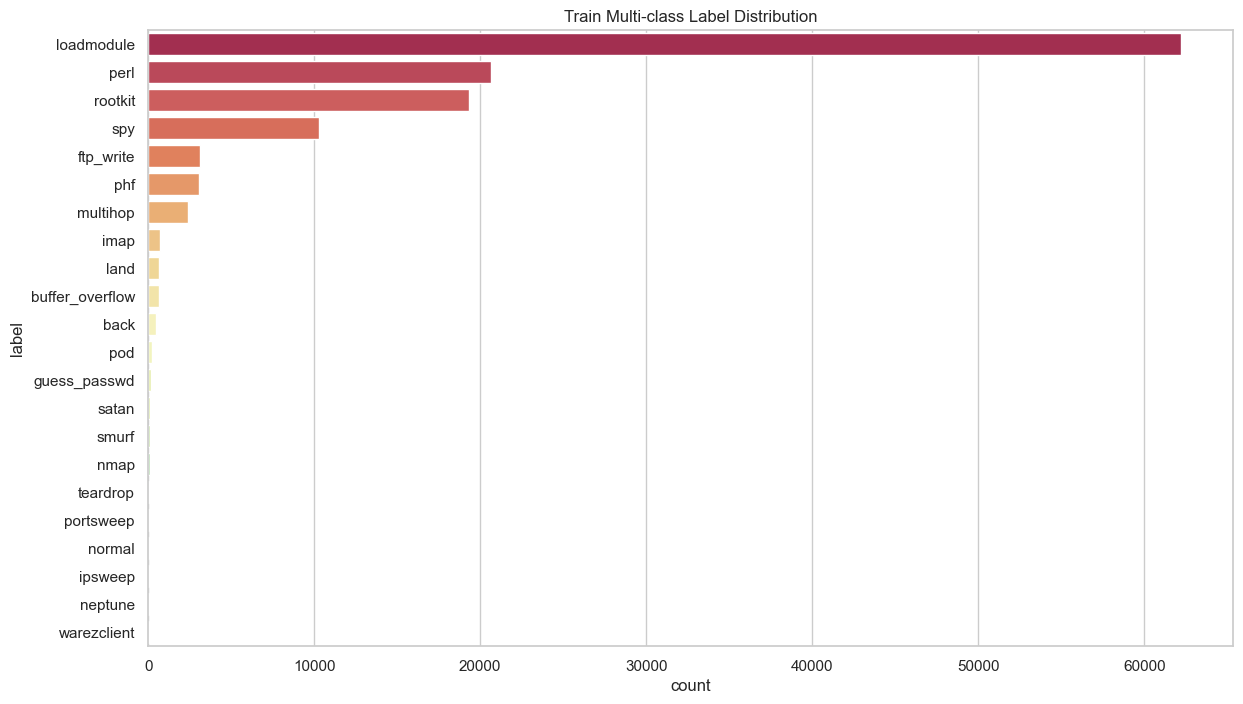

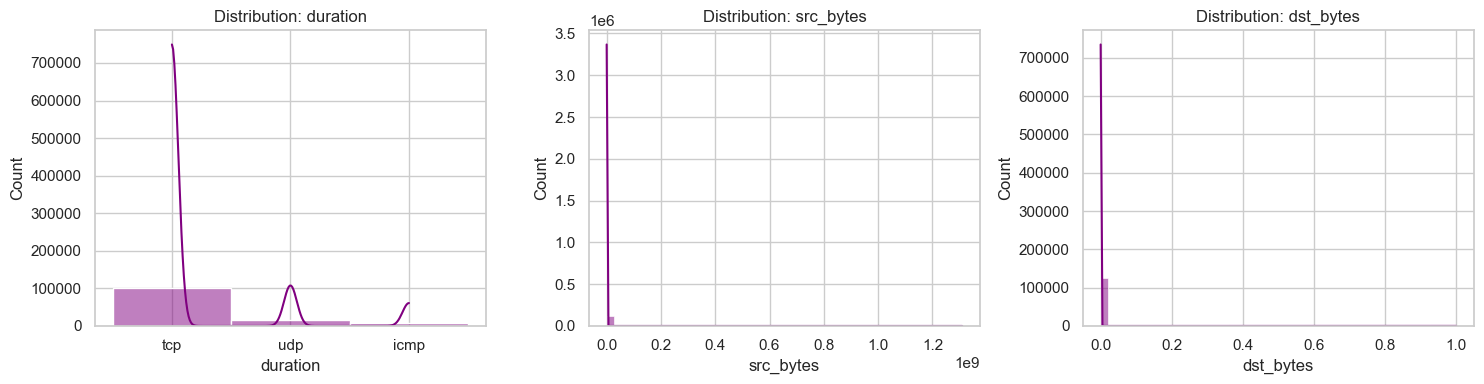

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_16424\1190070129.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='protocol_type', data=X_train, palette='pastel')


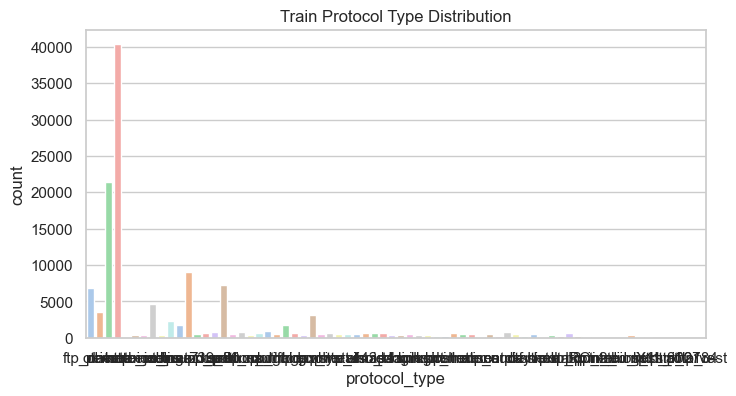

Training Logistic Regression...


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Train accuracy: 0.7074
Test accuracy: 0.5641


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Classification Report (Test):
                 precision    recall  f1-score   support

           back     0.0000    0.0000    0.0000       513
buffer_overflow     0.1216    0.0781    0.0951       461
      ftp_write     0.2847    0.0332    0.0594      1176
   guess_passwd     0.0000    0.0000    0.0000       106
           imap     0.0833    0.0041    0.0078       486
        ipsweep     0.0000    0.0000    0.0000       116
           land     0.0132    0.0027    0.0045       730
     loadmodule     0.7872    0.9591    0.8647     10694
       multihop     0.1434    0.0597    0.0843       670
        neptune     0.0000    0.0000    0.0000        87
           nmap     0.0000    0.0000    0.0000       157
         normal     0.0000    0.0000    0.0000       123
           perl     0.3482    0.4396    0.3886      2882
            phf     0.1336    0.0251    0.0423      1154
            pod     0.2727    0.0154    0.0291       195
      portsweep     0.0000    0.0000    0.0000       100


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Classification Report (Test):
                 precision    recall  f1-score   support

           back     0.1386    0.0273    0.0456       513
buffer_overflow     0.2258    0.0152    0.0285       461
      ftp_write     0.5123    0.1420    0.2224      1176
   guess_passwd     0.0392    0.0189    0.0255       106
           imap     0.1667    0.0185    0.0333       486
        ipsweep     0.0000    0.0000    0.0000       116
           land     0.1684    0.0658    0.0946       730
     loadmodule     0.7801    0.9739    0.8663     10694
       multihop     0.3778    0.1776    0.2416       670
        neptune     0.0000    0.0000    0.0000        87
           nmap     0.0000    0.0000    0.0000       157
         normal     0.2500    0.0163    0.0305       123
           perl     0.5358    0.6600    0.5914      2882
            phf     0.3832    0.0910    0.1471      1154
            pod     0.0720    0.0462    0.0563       195
      portsweep     0.0185    0.0100    0.0130       100


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Classification Report (Test):
                 precision    recall  f1-score   support

           back     0.0386    0.0409    0.0397       513
buffer_overflow     0.1778    0.0174    0.0316       461
      ftp_write     0.3171    0.0221    0.0413      1176
   guess_passwd     0.0091    0.0283    0.0138       106
           imap     0.0526    0.0062    0.0110       486
        ipsweep     0.0000    0.0000    0.0000       116
           land     0.1667    0.0055    0.0106       730
     loadmodule     0.8065    0.9693    0.8805     10694
       multihop     0.1622    0.0627    0.0904       670
        neptune     0.0000    0.0000    0.0000        87
           nmap     0.0000    0.0000    0.0000       157
         normal     0.1250    0.0163    0.0288       123
           perl     0.5358    0.6329    0.5803      2882
            phf     0.3041    0.1144    0.1662      1154
            pod     0.0000    0.0000    0.0000       195
      portsweep     0.2000    0.0100    0.0190       100


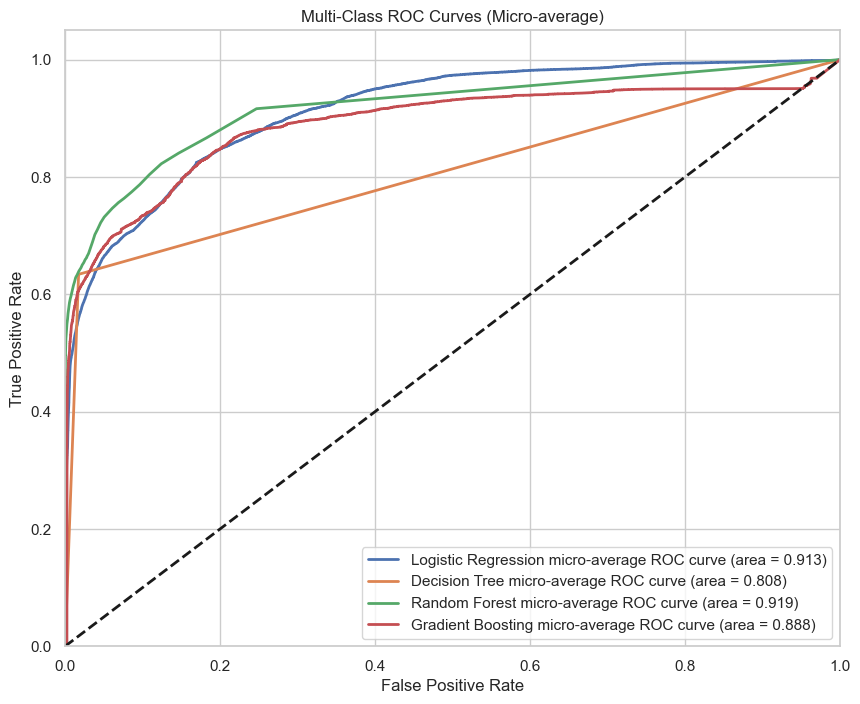

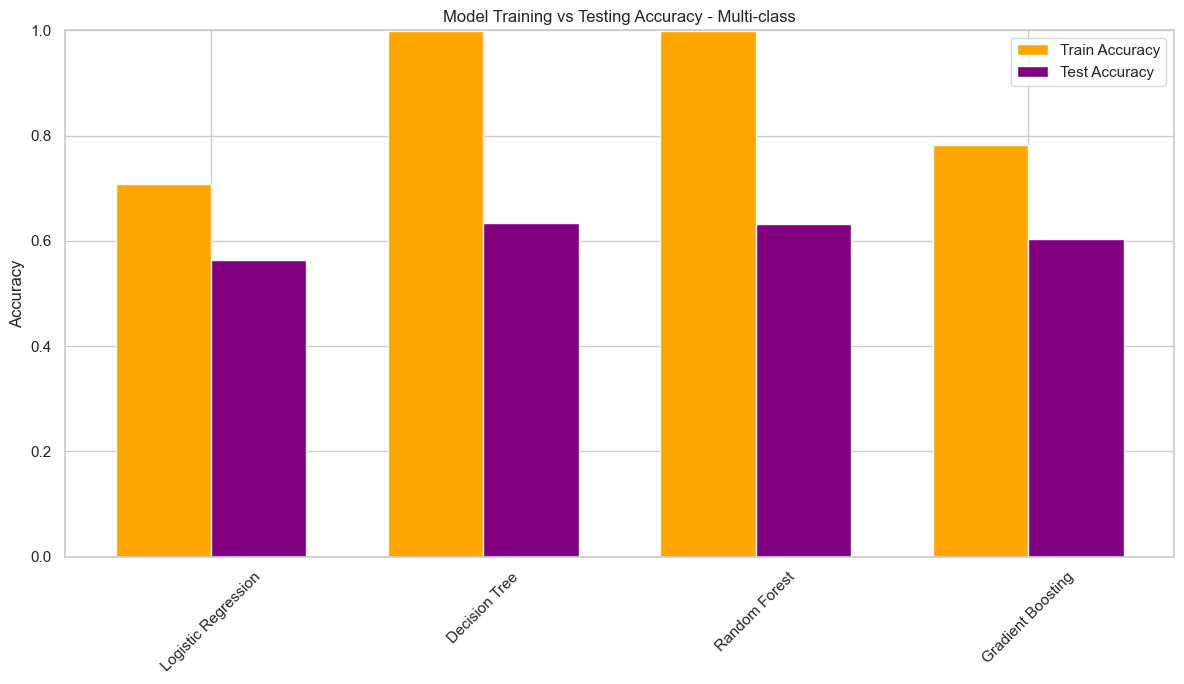

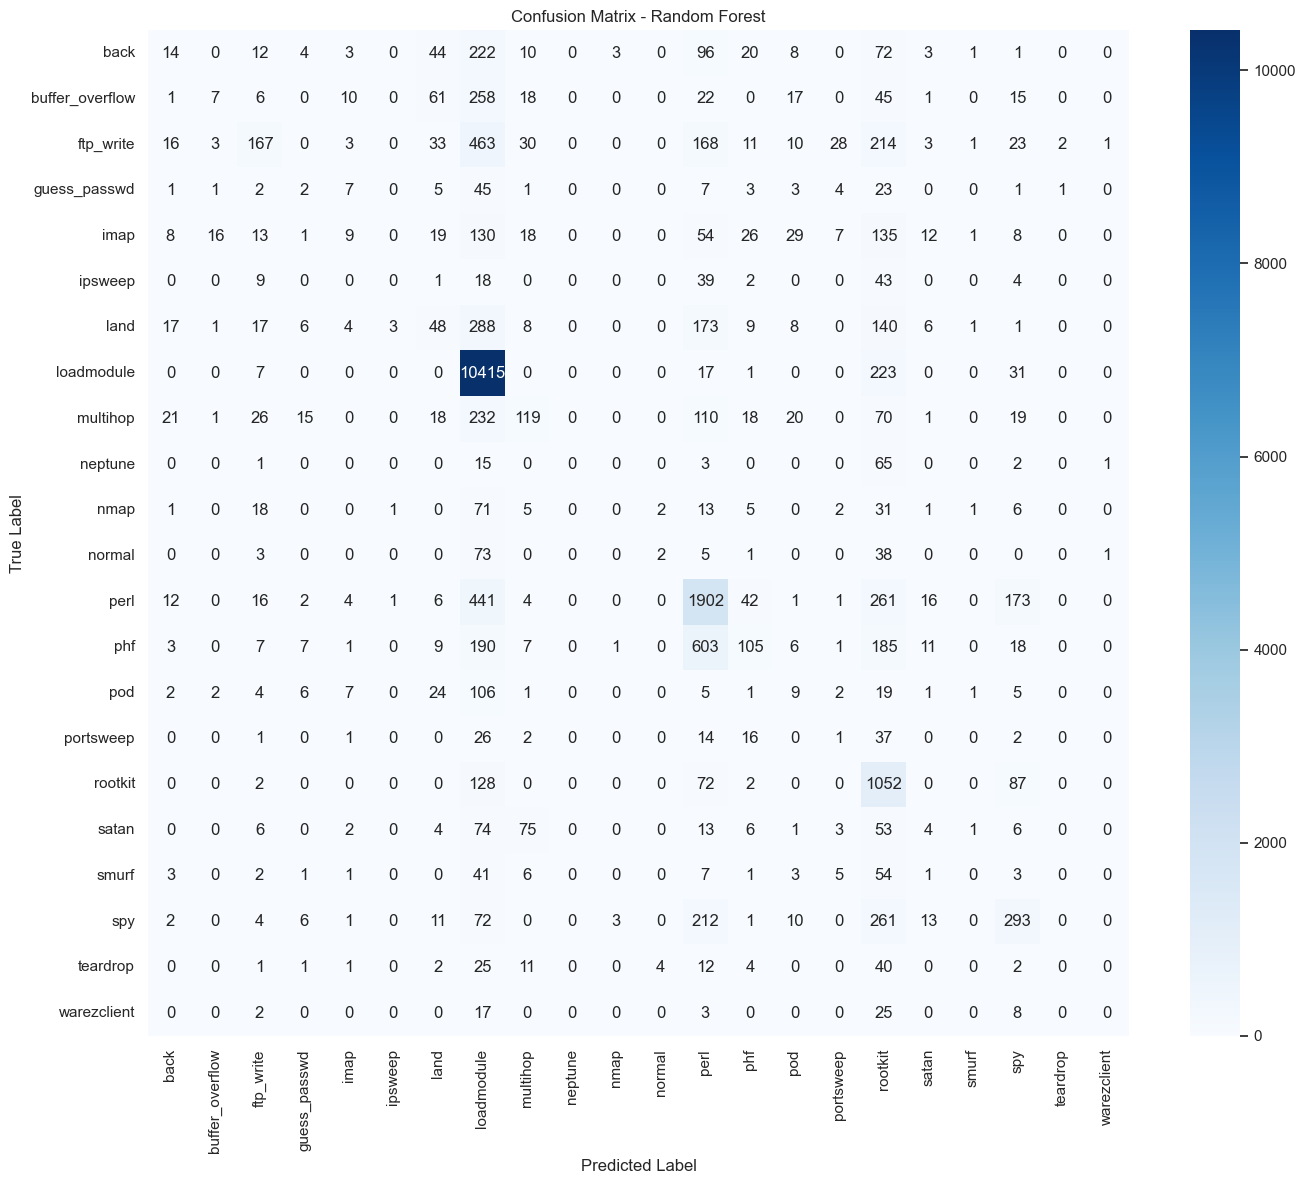

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

sns.set(style='whitegrid')

# Load NSL-KDD Dataset
column_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label"
]

train_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTrain+.txt'  # Update your file path here
test_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTest+.txt'

train_df = pd.read_csv(train_file, names=column_names)
test_df = pd.read_csv(test_file, names=column_names)

# Map integers to attack names 
label_map = {
    0:'normal',1:'neptune',2:'warezclient',3:'ipsweep',4:'portsweep',5:'teardrop',
    6:'nmap',7:'satan',8:'smurf',9:'guess_passwd',10:'pod',11:'buffer_overflow',
    12:'imap',13:'back',14:'land',15:'ftp_write',16:'multihop',17:'phf',
    18:'perl',19:'spy',20:'rootkit',21:'loadmodule'
}

train_df['label'] = train_df['label'].map(label_map)
test_df['label'] = test_df['label'].map(label_map)

# Data Cleaning
train_df.drop_duplicates(inplace=True)
test_df.drop_duplicates(inplace=True)

# Visualize multi-class distribution
plt.figure(figsize=(14,8))
sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index, palette='Spectral')
plt.title('Train Multi-class Label Distribution')
plt.show()

# Prepare features and labels
X_train = train_df.drop(columns=['label'])
y_train = train_df['label']
X_test = test_df.drop(columns=['label'])
y_test = test_df['label']

categorical_features = ['protocol_type', 'service', 'flag']
numeric_features = [col for col in X_train.columns if col not in categorical_features]

# Visualize numeric features distribution
plt.figure(figsize=(15,4))
for i, col in enumerate(numeric_features[:3]):
    plt.subplot(1,3,i+1)
    sns.histplot(X_train[col], bins=50, kde=True, color='purple')
    plt.title(f'Distribution: {col}')
plt.tight_layout()
plt.show()

# Visualize a categorical feature frequency
plt.figure(figsize=(8,4))
sns.countplot(x='protocol_type', data=X_train, palette='pastel')
plt.title('Train Protocol Type Distribution')
plt.show()

# Convert numerics properly and fill NAs
for col in numeric_features:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

X_train[numeric_features] = X_train[numeric_features].fillna(0)
X_test[numeric_features] = X_test[numeric_features].fillna(0)

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Binarize labels for ROC (support multi-class ROC)
unique_classes = sorted(y_train.unique())
y_train_bin = label_binarize(y_train, classes=unique_classes)
y_test_bin = label_binarize(y_test, classes=unique_classes)

# Define Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=300,solver='saga'),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(),
}

train_acc = {}
test_acc = {}

plt.figure(figsize=(10,8))
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_processed, y_train)

    y_train_pred = model.predict(X_train_processed)
    y_test_pred = model.predict(X_test_processed)

    train_acc[name] = accuracy_score(y_train, y_train_pred)
    test_acc[name] = accuracy_score(y_test, y_test_pred)

    print(f"Train accuracy: {train_acc[name]:.4f}")
    print(f"Test accuracy: {test_acc[name]:.4f}")
    print(f"Classification Report (Test):\n{classification_report(y_test, y_test_pred, digits=4)}")

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_processed)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test_processed)
        if y_score.ndim == 1:
            y_score = np.vstack([1 - y_score, y_score]).T
    else:
        continue

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(len(unique_classes)):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Micro-average ROC curve
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    plt.plot(fpr["micro"], tpr["micro"], lw=2,
             label=f'{name} micro-average ROC curve (area = {roc_auc["micro"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curves (Micro-average)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Plot accuracy comparisons
labels = list(models.keys())
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12,7))
rects1 = ax.bar(x - width/2, [train_acc[l] for l in labels], width, label='Train Accuracy', color='orange')
rects2 = ax.bar(x + width/2, [test_acc[l] for l in labels], width, label='Test Accuracy', color='purple')

ax.set_ylabel('Accuracy')
ax.set_title('Model Training vs Testing Accuracy - Multi-class')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

# Confusion matrix for Random Forest (example)
best_model = models['Random Forest']
y_pred = best_model.predict(X_test_processed)

plt.figure(figsize=(14,12))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_classes, yticklabels=unique_classes)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


Using label column: Label


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26980\993809560.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[label_col], order=df[label_col].value_counts().index, palette='Spectral')


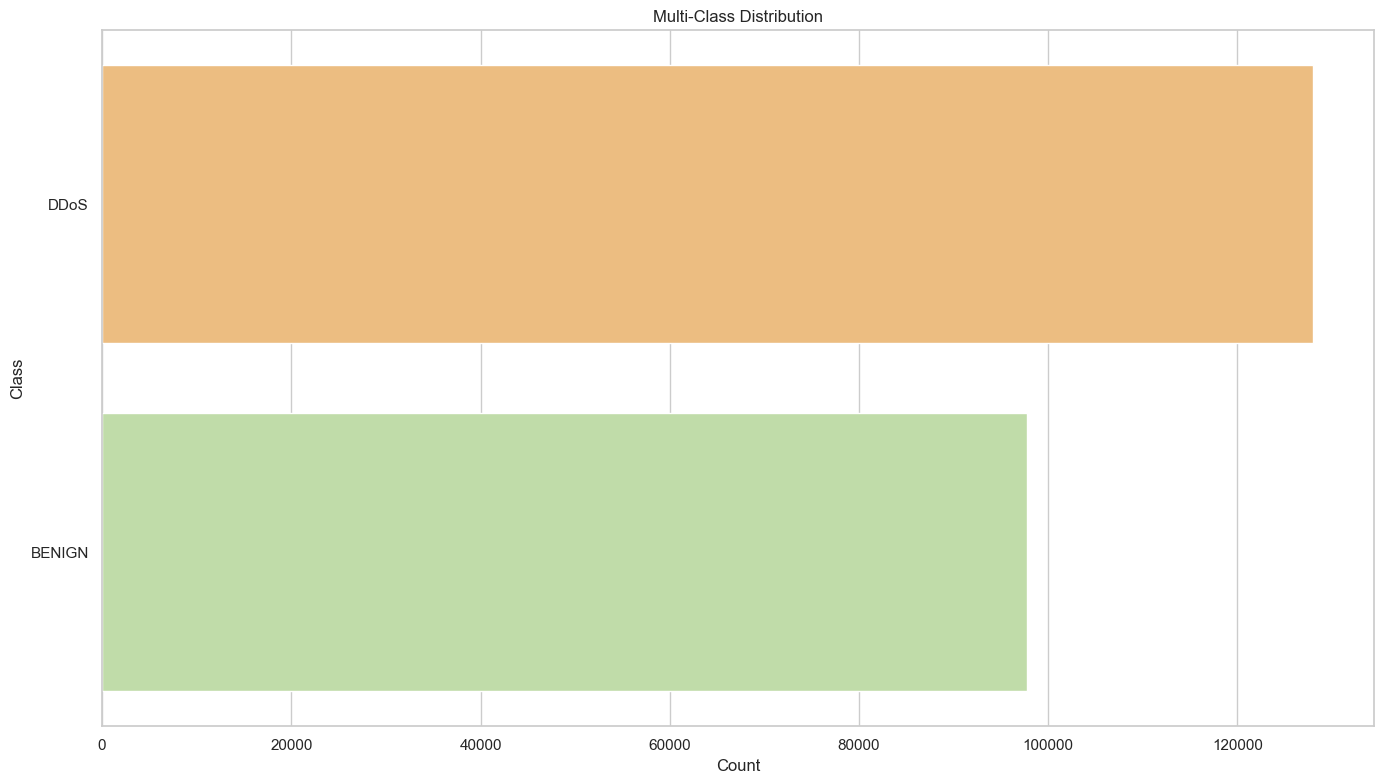

Missing values before dropping: 4
Missing values after dropping: 0
Duplicates before dropping: 2633
Duplicates after dropping: 0


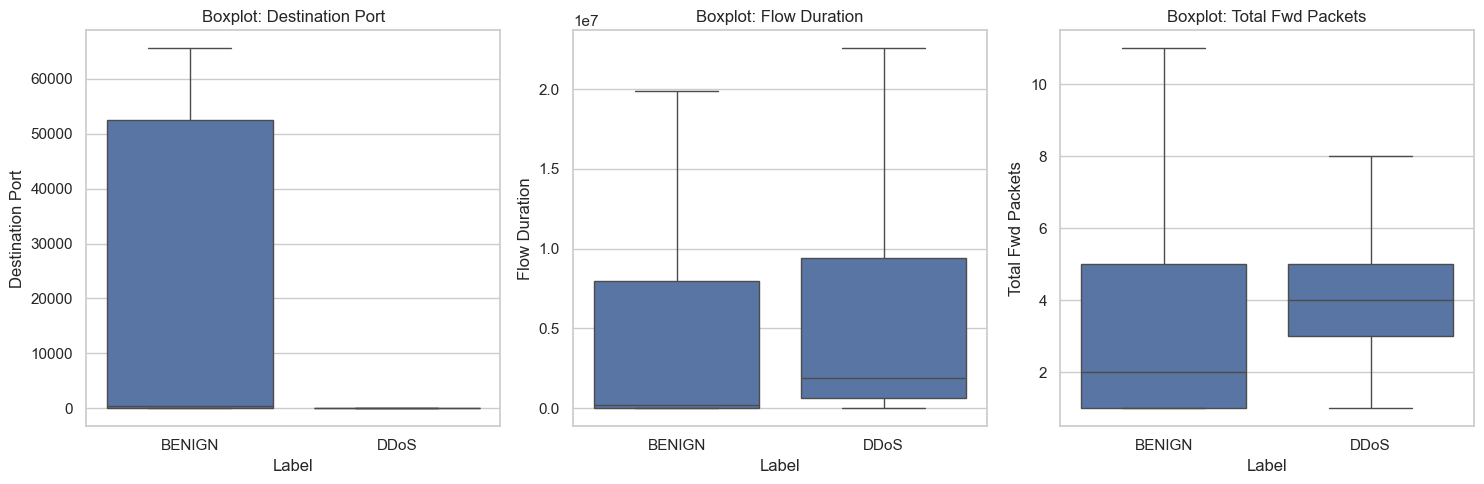

Training Logistic Regression...
Train accuracy: 0.9903
Test accuracy: 0.9900
Test Precision (macro): 0.9914
Test Recall (macro): 0.9883
Test F1-score (macro): 0.9897
Classification report for Logistic Regression:
              precision    recall  f1-score   support

      BENIGN     0.9996    0.9769    0.9881     28528
        DDoS     0.9831    0.9997    0.9914     38405

    accuracy                         0.9900     66933
   macro avg     0.9914    0.9883    0.9897     66933
weighted avg     0.9902    0.9900    0.9900     66933

Training Decision Tree...
Train accuracy: 1.0000
Test accuracy: 0.9998
Test Precision (macro): 0.9998
Test Recall (macro): 0.9998
Test F1-score (macro): 0.9998
Classification report for Decision Tree:
              precision    recall  f1-score   support

      BENIGN     0.9997    0.9999    0.9998     28528
        DDoS     0.9999    0.9998    0.9998     38405

    accuracy                         0.9998     66933
   macro avg     0.9998    0.9998    0.99

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26980\993809560.py:165: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


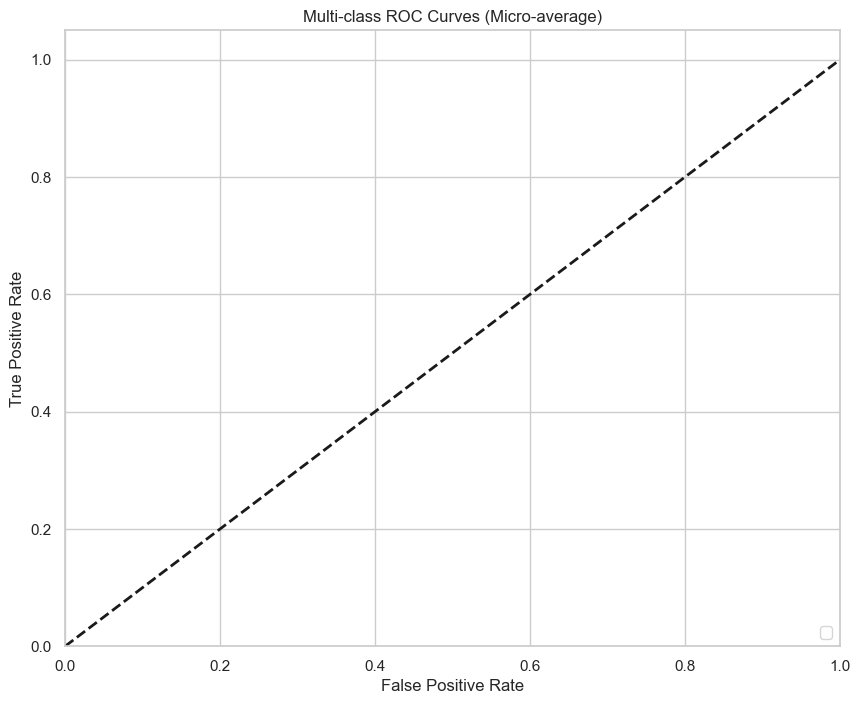

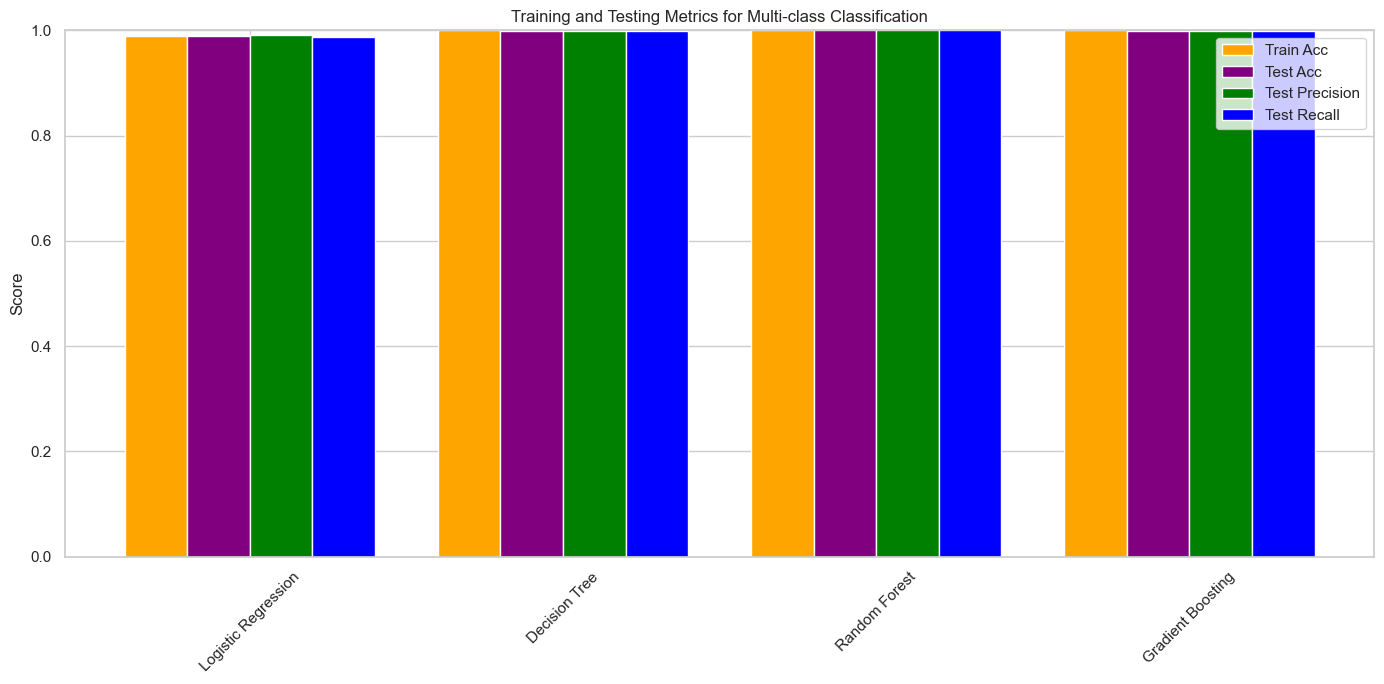

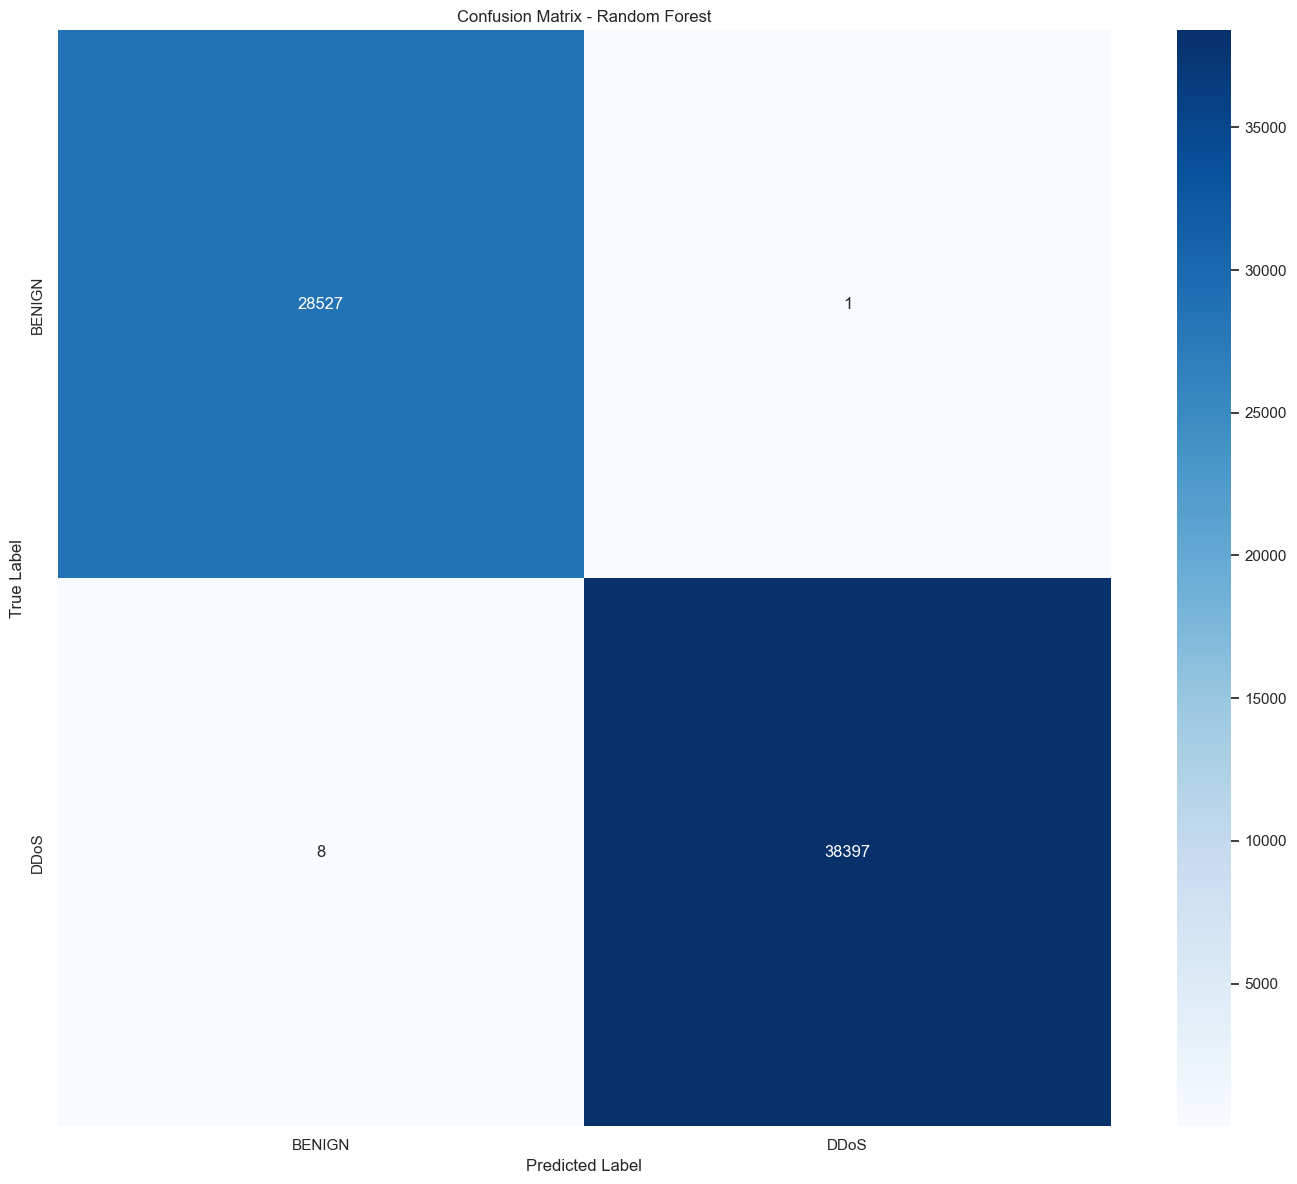

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             roc_curve, auc, precision_score, recall_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

sns.set(style='whitegrid')

# Step 1: Load dataset
df = pd.read_csv(r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\CICIDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

# Auto-detect label column
df.columns = df.columns.str.strip()
label_candidates = ['Label', 'label', 'Flow Label', 'FlowLabel']
label_col = None
for col in label_candidates:
    if col in df.columns:
        label_col = col
        print(f"Using label column: {label_col}")
        break
if label_col is None:
    raise KeyError("Label column not found.")

# Step 2: Visualize class distribution
plt.figure(figsize=(14, 8))
sns.countplot(y=df[label_col], order=df[label_col].value_counts().index, palette='Spectral')
plt.title('Multi-Class Distribution')
plt.xlabel('Count')
plt.ylabel('Class')
plt.tight_layout()
plt.show()

# Step 3: Data cleaning
print(f"Missing values before dropping: {df.isnull().sum().sum()}")
df.dropna(inplace=True)
print(f"Missing values after dropping: {df.isnull().sum().sum()}")

print(f"Duplicates before dropping: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Duplicates after dropping: {df.duplicated().sum()}")

# Step 4: Prepare features and target
X = df.drop(columns=[label_col])
y = df[label_col]

# Step 5: Identify categorical & numeric features
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

# Step 6: Numeric features distribution
plt.figure(figsize=(15, 5))
for i, col in enumerate(numeric_features[:3]):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x=y, y=X[col], showfliers=False)
    plt.title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

# Step 7: Plot categorical distribution (if any)
if categorical_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=categorical_features[0], data=X, palette='pastel')
    plt.title(f'Distribution of {categorical_features[0]}')
    plt.tight_layout()
    plt.show()

# Step 8: Clean numeric data
X[numeric_features] = X[numeric_features].replace([np.inf, -np.inf], np.nan)
X[numeric_features] = X[numeric_features].fillna(0)
X[numeric_features] = X[numeric_features].clip(lower=-1e10, upper=1e10)

# Step 9: Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

X_processed = preprocessor.fit_transform(X)

# Step 10: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.3, stratify=y, random_state=42
)

# Step 11: Binarize labels for ROC
unique_classes = sorted(y.unique())
y_train_bin = label_binarize(y_train, classes=unique_classes)
y_test_bin = label_binarize(y_test, classes=unique_classes)

# Step 12: Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(),
}

train_acc, test_acc = dict(), dict()
test_precision, test_recall, test_f1 = dict(), dict(), dict()

plt.figure(figsize=(10, 8))

# Step 13: Train models, evaluate metrics, and plot ROC curves
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc[name] = accuracy_score(y_train, y_train_pred)
    test_acc[name] = accuracy_score(y_test, y_test_pred)

    # Macro-average precision, recall, and f1 scores
    test_precision[name] = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
    test_recall[name] = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
    test_f1[name] = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

    print(f"Train accuracy: {train_acc[name]:.4f}")
    print(f"Test accuracy: {test_acc[name]:.4f}")
    print(f"Test Precision (macro): {test_precision[name]:.4f}")
    print(f"Test Recall (macro): {test_recall[name]:.4f}")
    print(f"Test F1-score (macro): {test_f1[name]:.4f}")
    print(f"Classification report for {name}:\n{classification_report(y_test, y_test_pred, digits=4)}")

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    if y_score.ndim == 1:
        # convert shape (n_samples,) to (n_samples, 2)
        y_score = np.vstack([-y_score, y_score]).T
    else:
        continue

    for i in range(len(unique_classes)):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Calculate micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    plt.plot(
        fpr["micro"],
        tpr["micro"],
        lw=2,
        label=f"{name} micro-average ROC (area = {roc_auc['micro']:.3f})",
    )

plt.plot([0, 1], [0, 1], "k--", lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curves (Micro-average)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# Step 14: Plot accuracy, precision, recall, and f1 score comparisons
labels = list(models.keys())
x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 7))
rects1 = ax.bar(x - 1.5 * width, [train_acc[l] for l in labels], width, label="Train Acc", color="orange")
rects2 = ax.bar(x - 0.5 * width, [test_acc[l] for l in labels], width, label="Test Acc", color="purple")
rects3 = ax.bar(x + 0.5 * width, [test_precision[l] for l in labels], width, label="Test Precision", color="green")
rects4 = ax.bar(x + 1.5 * width, [test_recall[l] for l in labels], width, label="Test Recall", color="blue")

ax.set_ylabel("Score")
ax.set_title("Training and Testing Metrics for Multi-class Classification")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


# Step 15: Confusion matrix for best model (Random Forest)
best_model = models["Random Forest"]
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=unique_classes, yticklabels=unique_classes)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26980\1447972359.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[label_col], order=df[label_col].value_counts().index, palette='Spectral')


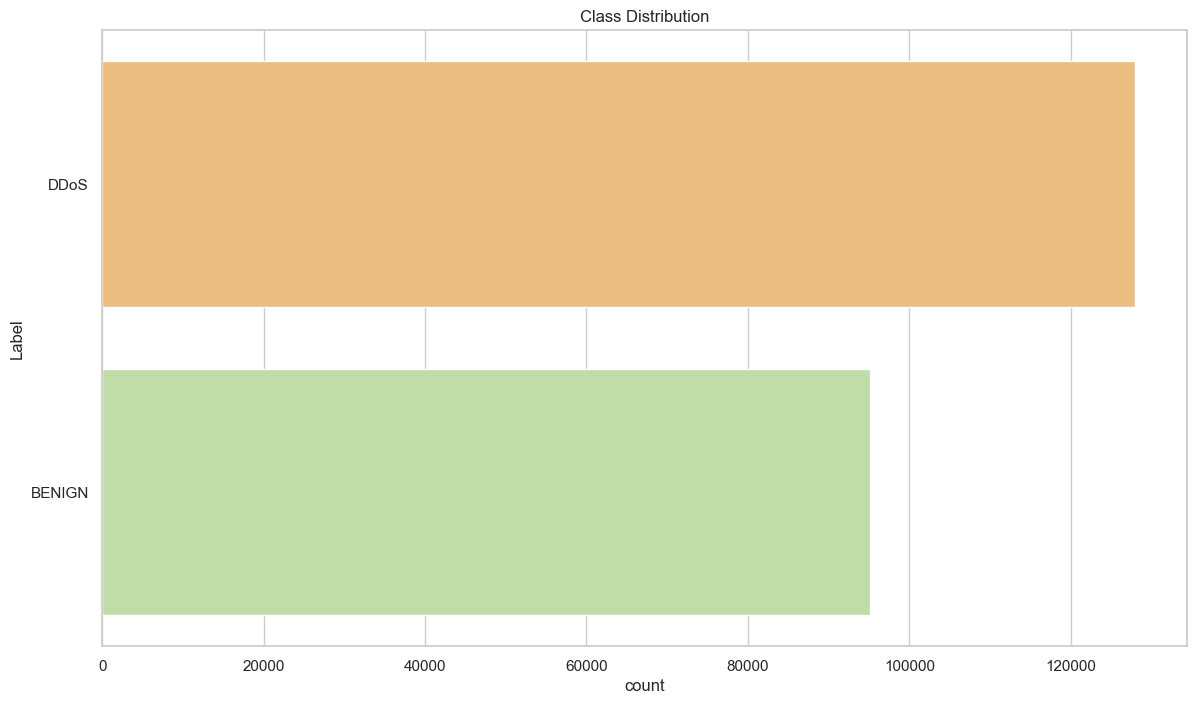

Training Logistic Regression
Train accuracy: 0.9903
Test accuracy: 0.9900
Precision (macro): 0.9914
Recall (macro): 0.9883
F1 (macro): 0.9897
              precision    recall  f1-score   support

      BENIGN       1.00      0.98      0.99     28528
        DDoS       0.98      1.00      0.99     38405

    accuracy                           0.99     66933
   macro avg       0.99      0.99      0.99     66933
weighted avg       0.99      0.99      0.99     66933

Training Decision Tree
Train accuracy: 1.0000
Test accuracy: 0.9998
Precision (macro): 0.9998
Recall (macro): 0.9998
F1 (macro): 0.9998
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     28528
        DDoS       1.00      1.00      1.00     38405

    accuracy                           1.00     66933
   macro avg       1.00      1.00      1.00     66933
weighted avg       1.00      1.00      1.00     66933

Training Random Forest
Train accuracy: 1.0000
Test accuracy: 0.9999


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26980\1447972359.py:132: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


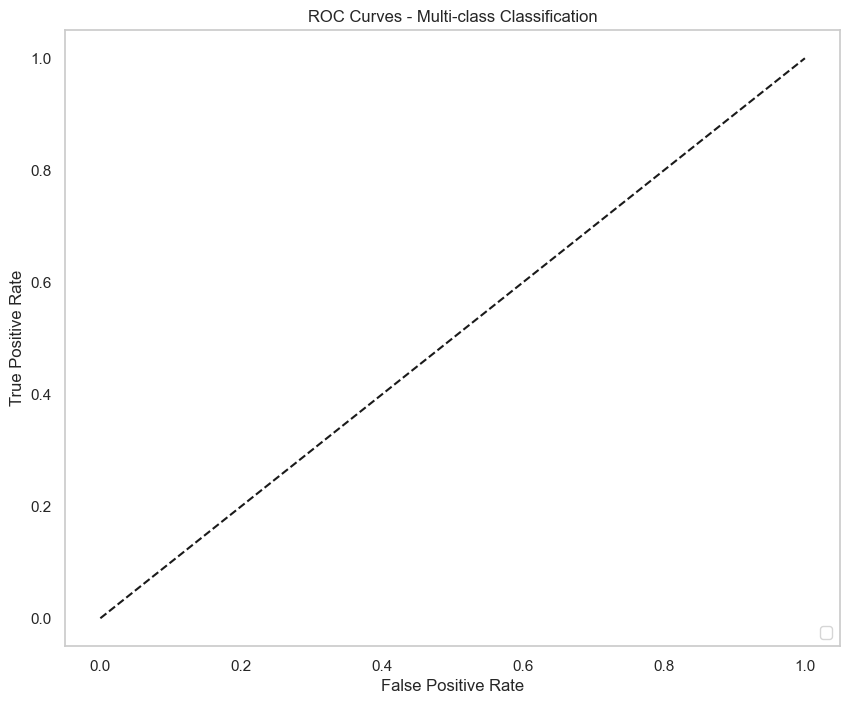

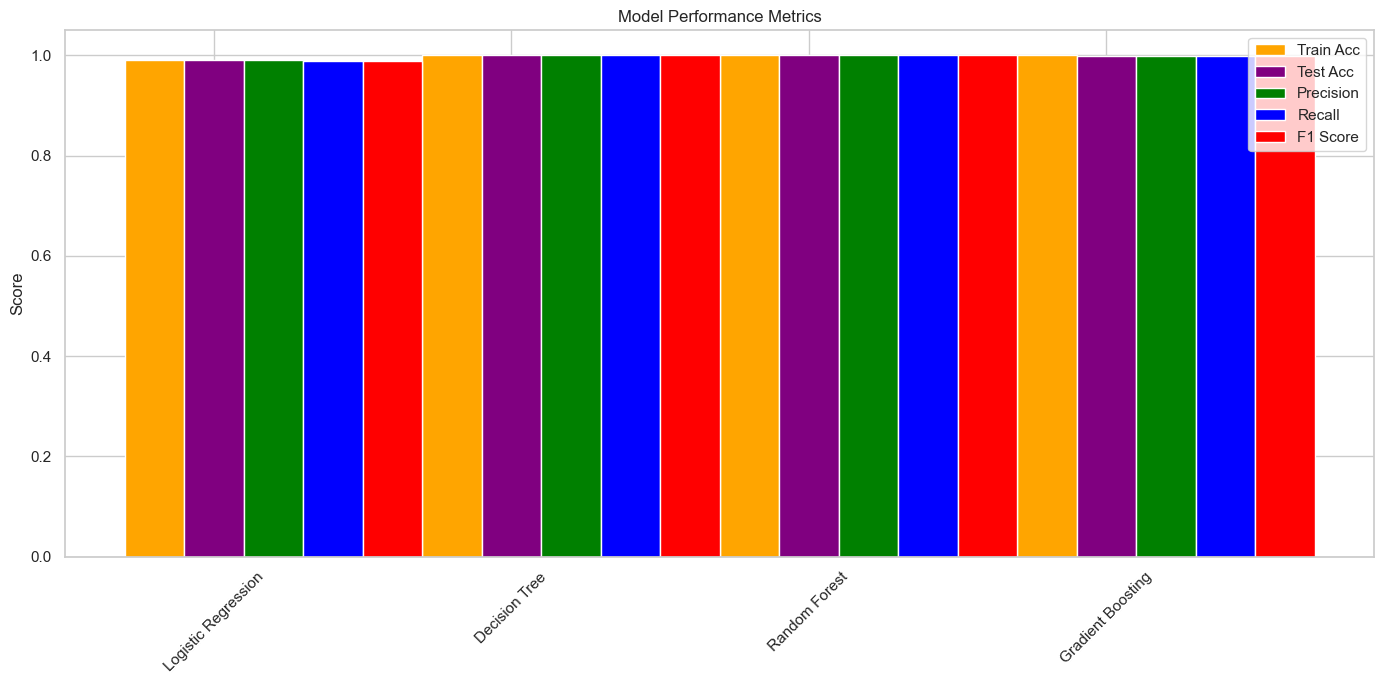

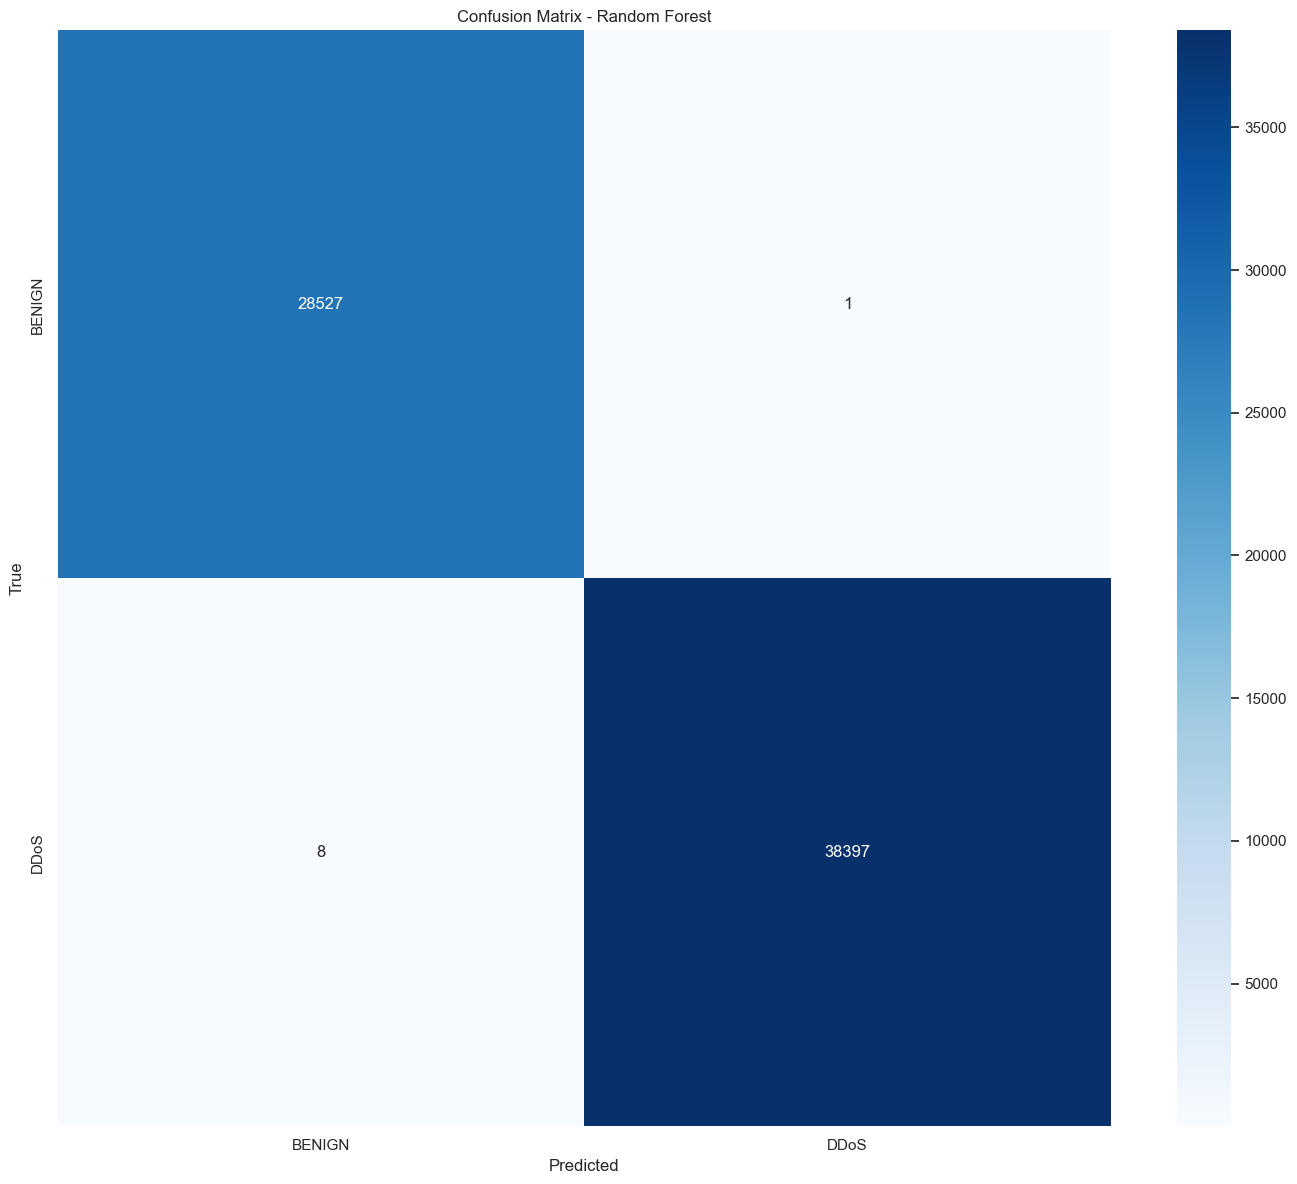

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

sns.set(style='whitegrid')

# Load data
df = pd.read_csv(r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\CICIDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')  
# Inspect columns and cleanup
print(df.columns)
df.columns = df.columns.str.strip()
print(df.columns)


# Detect label column
label_col_candidates = ['Label', 'label', 'Flow Label', 'FlowLabel']
label_col = None
for col in label_col_candidates:
    if col in df.columns:
        label_col = col
        print(f"Using label column: {label_col}")
        break
if not label_col:
    raise KeyError('Label column not found.')

# Clean data
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# Visualize
plt.figure(figsize=(14,8))
sns.countplot(y=df[label_col], order=df[label_col].value_counts().index, palette='Spectral')
plt.title('Class Distribution')
plt.show()

# Features, target
X = df.drop(columns=[label_col])
y = df[label_col]

# Feature types
cat_feats = X.select_dtypes(include='object').columns.tolist()
num_feats = X.select_dtypes(include=np.number).columns.tolist()

# Clean numeric features
X[num_feats] = X[num_feats].replace([np.inf, -np.inf], np.nan).fillna(0)

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats)
])

X_processed = preprocessor.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.3, stratify=y, random_state=42)

# Binarize labels for ROC
unique_classes = sorted(y.unique())
y_train_bin = label_binarize(y_train, classes=unique_classes)
y_test_bin = label_binarize(y_test, classes=unique_classes)

# Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(),
}

train_acc, test_acc = {}, {}
precision, recall, f1 = {}, {},{}

plt.figure(figsize=(10,8))

for name, model in models.items():
    print(f"Training {name}")
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_acc[name] = accuracy_score(y_train, y_train_pred)
    test_acc[name] = accuracy_score(y_test, y_test_pred)
    
    precision[name] = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
    recall[name] = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
    f1[name] = f1_score(y_test, y_test_pred, average='macro', zero_division=0)
    
    print(f"Train accuracy: {train_acc[name]:.4f}")
    print(f"Test accuracy: {test_acc[name]:.4f}")
    print(f"Precision (macro): {precision[name]:.4f}")
    print(f"Recall (macro): {recall[name]:.4f}")
    print(f"F1 (macro): {f1[name]:.4f}")
    print(classification_report(y_test, y_test_pred))
    
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    if y_score.ndim == 1:
        y_score = np.vstack([-y_score, y_score]).T
    else:
        continue
    
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(len(unique_classes)):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Micro-average ROC curve
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    plt.plot(fpr["micro"], tpr["micro"], label=f"{name} micro-average ROC (AUC={roc_auc['micro']:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Multi-class Classification")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Plot evaluation metrics
labels = list(models.keys())
x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(14,7))
ax.bar(x - width, [train_acc[l] for l in labels], width, label="Train Acc", color="orange")
ax.bar(x, [test_acc[l] for l in labels], width, label="Test Acc", color="purple")
ax.bar(x + width, [precision[l] for l in labels], width, label="Precision", color="green")
ax.bar(x + 2 * width, [recall[l] for l in labels], width, label="Recall", color="blue")
ax.bar(x + 3 * width, [f1[l] for l in labels], width, label="F1 Score", color="red")

ax.set_ylabel("Score")
ax.set_title("Model Performance Metrics")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

# Confusion matrix of best model (Random Forest)
best_model = models["Random Forest"]
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14,12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=unique_classes, yticklabels=unique_classes)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()